# Gaming Toxicity Detection

**Authors:** Beibarys Nyussupov, Ruby Ngo, Paola Calle, Jett Forward


In [1]:
# libraries 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
import html as html_lib
from nltk.tokenize import TweetTokenizer


from pathlib import Path
import sys
PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.tokenizer import tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import html as html_lib
import os 
import spacy
nlp = spacy.load("en_core_web_sm")

# reproducibility
seed = 7524
np.random.seed(seed)

In [2]:
# data directories
DATA_DIR_WOT  = PROJECT_ROOT / "data/processed_data/wot/"
DATA_DIR_DOTA = PROJECT_ROOT / "data/processed_data/dota/"

## World of Tanks

In [3]:
# read parquet file
wot = pd.read_parquet(DATA_DIR_WOT / "wot.parquet")
# check 
print(f"Dataset shape: {wot.shape}")
print(f"Dataset first 5 rows:\n{wot.head(5)}\n")
print(f"Dataset info:")
wot.info()


Dataset shape: (49579, 3)
Dataset first 5 rows:
   index                        message  label
0  30702                        no rush    0.0
1  18607  whatever ... watch the replay    0.0
2  32901                        useless    1.0
3  25964                      3 gunmark    0.0
4  28643                            lol    0.0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49579 entries, 0 to 49578
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    49579 non-null  int64  
 1   message  49579 non-null  object 
 2   label    49579 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


### Exploratory Data Analysis (EDA)

| Class | Terminology |
|---|---|
| 0 | Non-Toxic |
| 1 | Insults and Flaming |
| 2 | Other Offensive Texts |
| 3 | Hate and Harassment |
| 4 | Threats |
| 5 | Extremism |

#### Class distribution

In [4]:
# Class balance check
print(f"Class distribution:\n{wot['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{wot['label'].value_counts(normalize=True)}")

Class distribution:
label
0.0    38993
1.0     6927
2.0     3191
3.0      373
4.0       68
5.0       27
Name: count, dtype: int64

Class distribution (normalized):
label
0.0    0.786482
1.0    0.139716
2.0    0.064362
3.0    0.007523
4.0    0.001372
5.0    0.000545
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_25992\3772814331.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\nyuss\AppData\Local\Temp\ipykernel_25992\3772814331.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


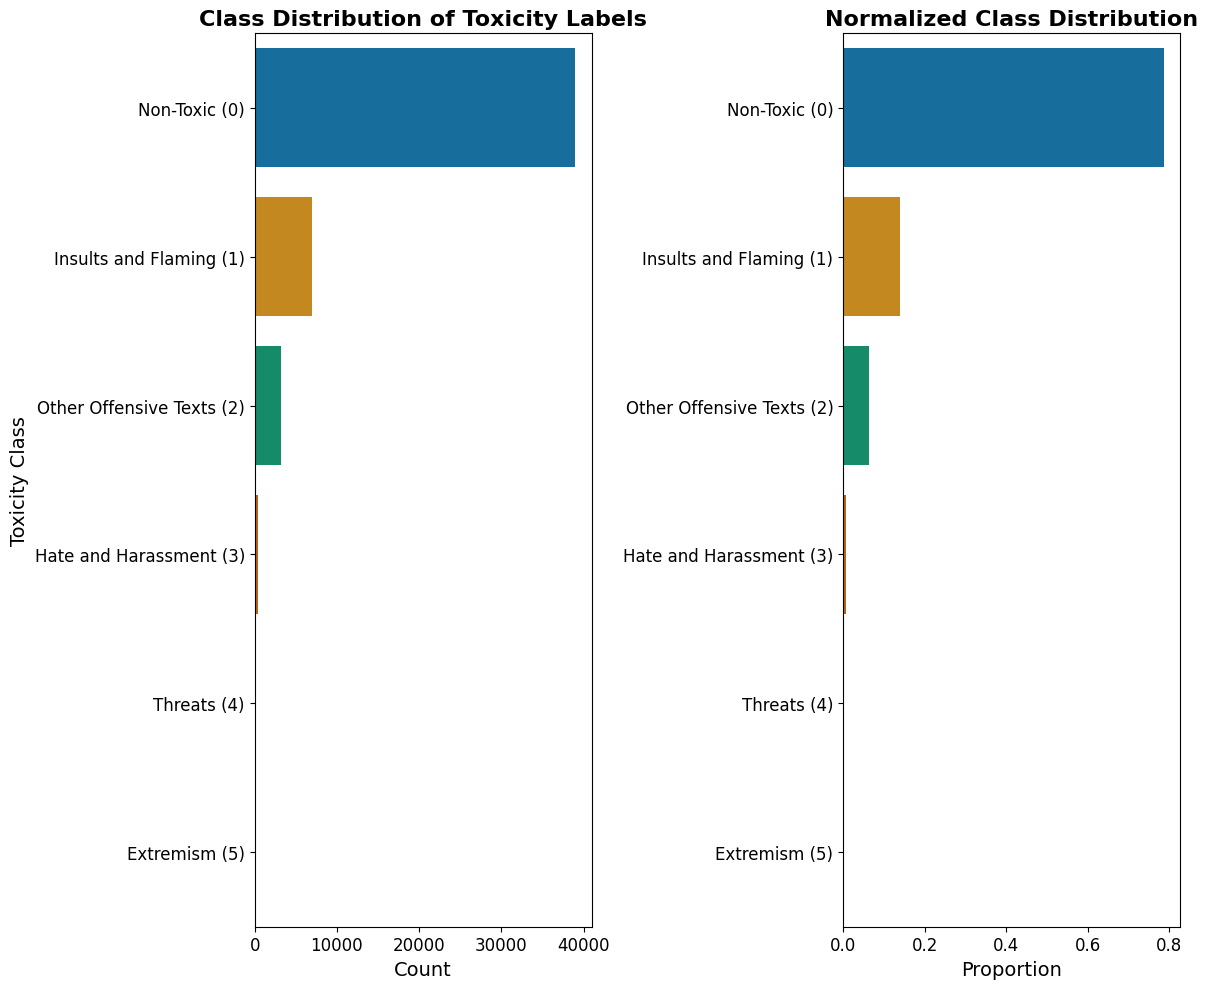

In [5]:
# Class balance plot + normalized class balance plot side by side

# class order and readable labels
class_order = [0, 1, 2, 3, 4, 5]
class_labels = [
    "Non-Toxic (0)",
    "Insults and Flaming (1)",
    "Other Offensive Texts (2)",
    "Hate and Harassment (3)",
    "Threats (4)",
    "Extremism (5)"
]

# map numeric labels to readable names
label_map = dict(zip(class_order, class_labels))
wot["label_name"] = wot["label"].map(label_map)

# normalized proportions
class_props = (
    wot["label"]
    .value_counts(normalize=True)
    .reindex(class_order)
)

# figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

# raw counts plot
sns.countplot(
    y="label_name",
    data=wot,
    order=class_labels,
    palette="colorblind",
    ax=axes[0]
)

# aesthetics
# title 
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=16)

# axis labels and ticks
axes[0].set_xlabel("Count", fontsize=14)
axes[0].set_ylabel("Toxicity Class", fontsize=14)

axes[0].tick_params(axis="y", labelsize=12)
axes[0].tick_params(axis="x", labelsize=12)


# normalized distribution
sns.barplot(
    x=class_props.values,
    y=class_labels,
    palette="colorblind",
    ax=axes[1]
)

# aesthetics 
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=16)

# axis labels and ticks 
axes[1].set_xlabel("Proportion", fontsize=14)

axes[1].tick_params(axis="y", labelsize=12)
axes[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

That gives us the idea that the class proportions are very imbalanced. We might experiment with binary vs multiclass classification later because of that. We could also merge minority labels to make it easier for model to learn data signals.

#### Non-English Messages (verification)

In [6]:
import re

NON_LATIN_SCRIPT = re.compile(
    r"[\u0400-\u04FF"   # Cyrillic
    r"\u4E00-\u9FFF"    # CJK unified ideographs
    r"\u3400-\u4DBF"    # CJK extension A
    r"\uF900-\uFAFF"    # CJK compatibility ideographs
    r"\u0600-\u06FF"    # Arabic
    r"\u0590-\u05FF"    # Hebrew
    r"\u3040-\u30FF"    # Japanese (Hiragana + Katakana)
    r"\uAC00-\uD7AF"    # Korean (Hangul syllables)
    r"\u1100-\u11FF"    # Korean (Hangul Jamo)
    r"\u0E00-\u0E7F"    # Thai
    r"\u0900-\u097F"    # Devanagari (Hindi)
    r"\u0980-\u09FF"    # Bengali
    r"\u0370-\u03FF"    # Greek
    r"\u10A0-\u10FF"    # Georgian
    r"\u0530-\u058F"    # Armenian
    r"\u1000-\u109F"    # Myanmar
    r"\u1780-\u17FF]"   # Khmer
)

non_english_count = wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(wot)) * 100:.2f}%")

Number of non-English script messages: 0
Percentage: 0.00%


In [7]:
# check 
wot[wot["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False)]

,index,message,label,label_name


We successfully deleted everything in cleaning phase. 

#### Number of words per document

In [8]:
# splitting the dataset 

# features and target
X = wot["message"]
y = wot["label"]

# First split: 10% for final testing, 90% remains for training/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, random_state=7524, shuffle = True, stratify= y)

# datasets 
# train
train_df = pd.DataFrame({
    "message": X_train,
    "label": y_train
}).reset_index(drop=True)

# validation 
validation_df = pd.DataFrame({
    "message": X_val,
    "label": y_val
}).reset_index(drop=True)

# check shapes 
print(f"Train dataset shape:{train_df.shape}\n")
print(f"Validation dataset shape:{validation_df.shape}\n")

Train dataset shape:(44621, 2)

Validation dataset shape:(4958, 2)



In [9]:
# summary statistics of comments
print("Summary statistics of comment lengths:")

# create new column with comment world lengths
train_df["comment_length"] = train_df["message"].str.split().str.len()

# summary statistics 
train_describe = train_df["comment_length"].describe()
train_describe 

Summary statistics of comment lengths:


count    44621.000000
mean         2.992492
std          2.515779
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         30.000000
Name: comment_length, dtype: float64

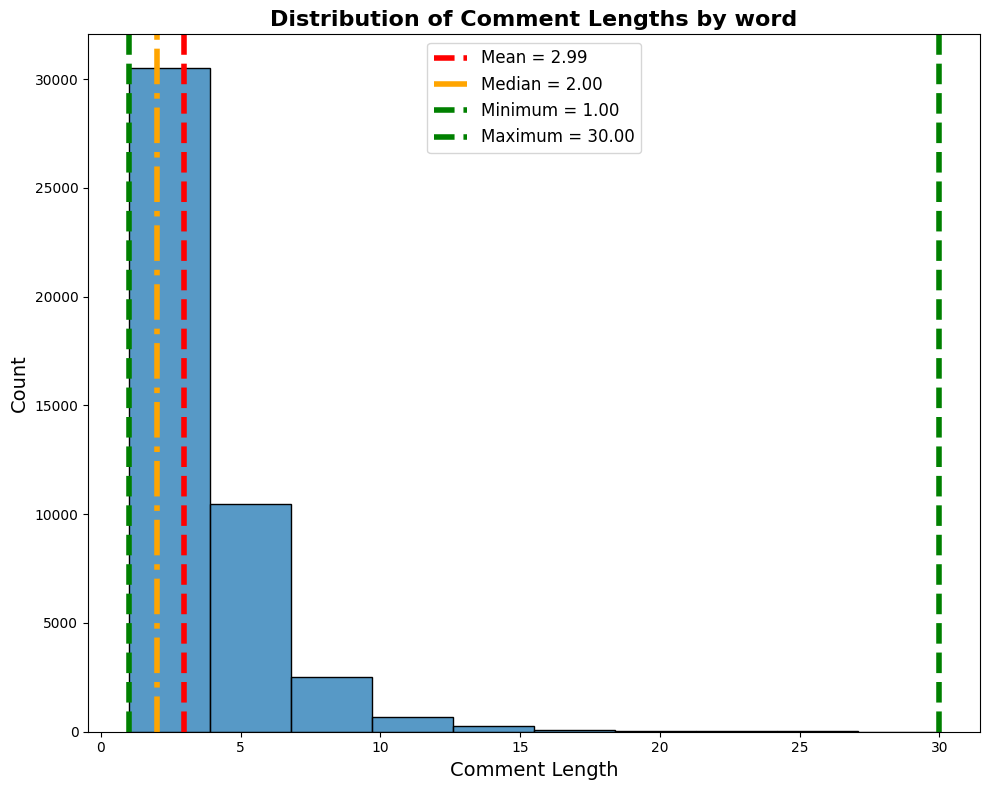

In [10]:
# distribution of world length 
# summary statistics
mean_len = train_df["comment_length"].mean()
median_len = train_df["comment_length"].median()
min_len = train_df["comment_length"].min()
max_len = train_df["comment_length"].max()

# plot
plt.figure(figsize=(10, 8))

# histogram plot
sns.histplot(
    train_df["comment_length"],
    bins=10,
    kde=False
)

# mean line
plt.axvline(
    mean_len,
    linestyle="--",
    linewidth=4,
    label=f"Mean = {mean_len:.2f}", 
    color = "red"
)

# median line
plt.axvline(
    median_len,
    linestyle="-.",
    linewidth=4,
    label=f"Median = {median_len:.2f}",
    color = "orange"
)

# min line 
plt.axvline(
    min_len,
    linestyle="--",
    linewidth=4,
    label=f"Minimum = {min_len:.2f}",
    color = "green"
)

# max line 
plt.axvline(
    max_len,
    linestyle="--",
    linewidth=4,
    label=f"Maximum = {max_len:.2f}",
    color = "green"
)

# title and labels
plt.title("Distribution of Comment Lengths by word", fontweight="bold", fontsize=16)

# xlabel
plt.xlabel("Comment Length", fontsize=14)

# ylabel
plt.ylabel("Count", fontsize=14)

# legend
plt.legend(fontsize=12)

# show the plot 
plt.tight_layout()
plt.show()

Messages are extremely short - median 2 words, max 30 in train data. Over 60% of messages are 1-3 words, confirming that gaming chat is reaction-driven rather than conversational. This justifies unigram + bigram TF-IDF: trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [11]:
# check messages 
# comments longer than or equal to the median top 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,go 3 min,3,0.0
1,fuckin yikes,2,1.0
2,gj idiots on hill...,4,1.0
4,oh yes the lost w- key,6,0.0
5,team i have a kv5 problem,6,0.0
6,25/2 idiote,2,1.0
7,all my helath went to artys,6,0.0
9,why I listened to you idk lol,7,0.0
10,THank you for your great support on left side,9,0.0
11,im a noob. just got it last week,8,1.0


In [12]:
# comments longer than or equal to the median bottom 10 words 
train_df[train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
44611,this will not work....,4,0.0
44612,Im Spotted at J7!,4,0.0
44613,sorry guys...thats is all from me :/,7,0.0
44614,Im Spotted at A6!,4,0.0
44615,dont die elc,3,0.0
44616,"yea,, 3 on 1 was more than i could handle",10,0.0
44617,it pens my turret at the front lol,8,0.0
44618,they are to slow,4,0.0
44619,learn support forst before capping,5,0.0
44620,go win\,2,0.0


This confirms that if we use `trigrams`, the model potentially might overfit to longer sentences without actually capturing the context.

In [13]:
# comments shoterter than the median top 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
3,damn,1,2.0
8,gg,1,0.0
13,gg,1,0.0
27,gg,1,0.0
31,please,1,0.0
32,yay,1,0.0
33,SZT,1,0.0
38,deff,1,0.0
40,ffuuu,1,2.0
43,gg,1,0.0


In [14]:
# comments shorter than the median bottom 10 words 
train_df[train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
44563,gg,1,0.0
44570,gg,1,0.0
44573,u2,1,0.0
44585,gj,1,0.0
44589,gg,1,0.0
44590,gg,1,0.0
44591,wow,1,0.0
44596,okay,1,0.0
44601,gj,1,0.0
44602,gg,1,0.0


#### Word Frequency analysis

In [15]:
# combine all messages
all_text = " ".join(X_train.astype(str))

# tokenize
words = all_text.split()

# frequency table
word_freq = pd.DataFrame(Counter(words).items(), 
                         columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)

# top 20
word_freq.head(20)

,word,count
30,gg,3331
99,at,2169
34,you,2087
98,Spotted,1831
97,Im,1817
12,the,1707
0,go,1507
17,i,1503
28,to,1319
88,is,1186


A lot of stop words, we might need to drop them later in pre-processing, since they do not reveal any contextual information. However we might need to think how to deal with stopwords which are part of the phrase, for example: `You` versus `Fuck you`.

In [16]:
# stopwords dictionary 
EXTRA = {
    # contractions sklearn misses
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve",

    # pure filler
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "nice", "sry",
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
    "elc", "ebr", "wg", "wot", "tier", "doing", "loose", "team", 
    "help", "afk", "lost", "dead", "commend", "pause",

    # Dota hero names — zero toxicity signal
    "abaddon", "alchemist", "axe", "bane", "batrider", "beastmaster",
    "bloodseeker", "brewmaster", "bristleback", "broodmother", "centaur",
    "chen", "clinkz", "clockwerk", "dazzle", "dawnbreaker", "disruptor",
    "doom", "enchantress", "enigma", "grimstroke", "gyrocopter", "hoodwink",
    "huskar", "invoker", "io", "jakiro", "juggernaut", "kunkka", "leshrac",
    "lich", "lifestealer", "lina", "lion", "luna", "lycan", "magnus",
    "marci", "mars", "medusa", "meepo", "mirana", "morphling", "muerta",
    "necrophos", "oracle", "pangolier", "phoenix", "puck", "pudge", "pugna",
    "razor", "riki", "rubick", "silencer", "slark", "slardar", "snapfire",
    "sniper", "spectre", "sven", "techies", "tidehunter", "timbersaw",
    "tinker", "tiny", "tusk", "underlord", "undying", "ursa", "viper",
    "visage", "warlock", "weaver", "zeus",

    # hero abbreviations
    "sf", "qop", "ta", "am", "es", "pa", "pl", "wk", "dk",
    "lc", "tb", "sk", "ns", "od", "wd", "sd", "ss", "kotl",
    "mk", "vs", "dp", "ck", "bh", "sb", "ember", "void", "storm",
    "jugg", "jug", "drow", "bara", "gyro", "legion", "rosh", "clock",
    "necro", "invo", "potm",
}

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'eh', 'elsewhere', 'just', 'nobody', 'kotl', 'broodmother', 'plz', 'as', 'every', 'didnt', 'alchemist', 'anything', 'myself', 'dazzle', 'has', 'gyrocopter', 'move', 'dp', 'mars', 'yet', 'anyway', 'many', 'back', 'wg', 'wanna', 'my', 'thereupon', 'therefore', 'tinker', 'ten', 'doesnt', 'lion', 'which', 'axe', 'amount', 'down', 'she', 'help', 'uh', 'jug', 'whereafter', 'mk', 'latterly', 'latter', 'fire', 'thick', 'forty', 'brewmaster', 'invo', 'mill', 'what', 'together', 'oh', 'juggernaut', 'ss', 'yourself', 'visage', 'is', 'becomes', 'well', 'void', 'take', 'hes', 'however', 'nah', 'six', 'of', 'hereby', 'although', 'up', 'in', 'whose', 'top', 're', 'twenty', 'jugg', 'mirana', 'could', 'though', 'always', 'riki', 'four', 'made', 'hereafter', 'gyro', 'by', 'puck', 'whereas', 'gl', 'had', 'they', 'if', 'slark', 'seems', 'dk', 'but', 'cant', 'game', 'wherever', 'rng', 'on', 'zeus', 'another', 'while', 'spot', 'qop', 'sometime', 'eleven', 'any', 'empty', 'beforehand', 'co', 'besi

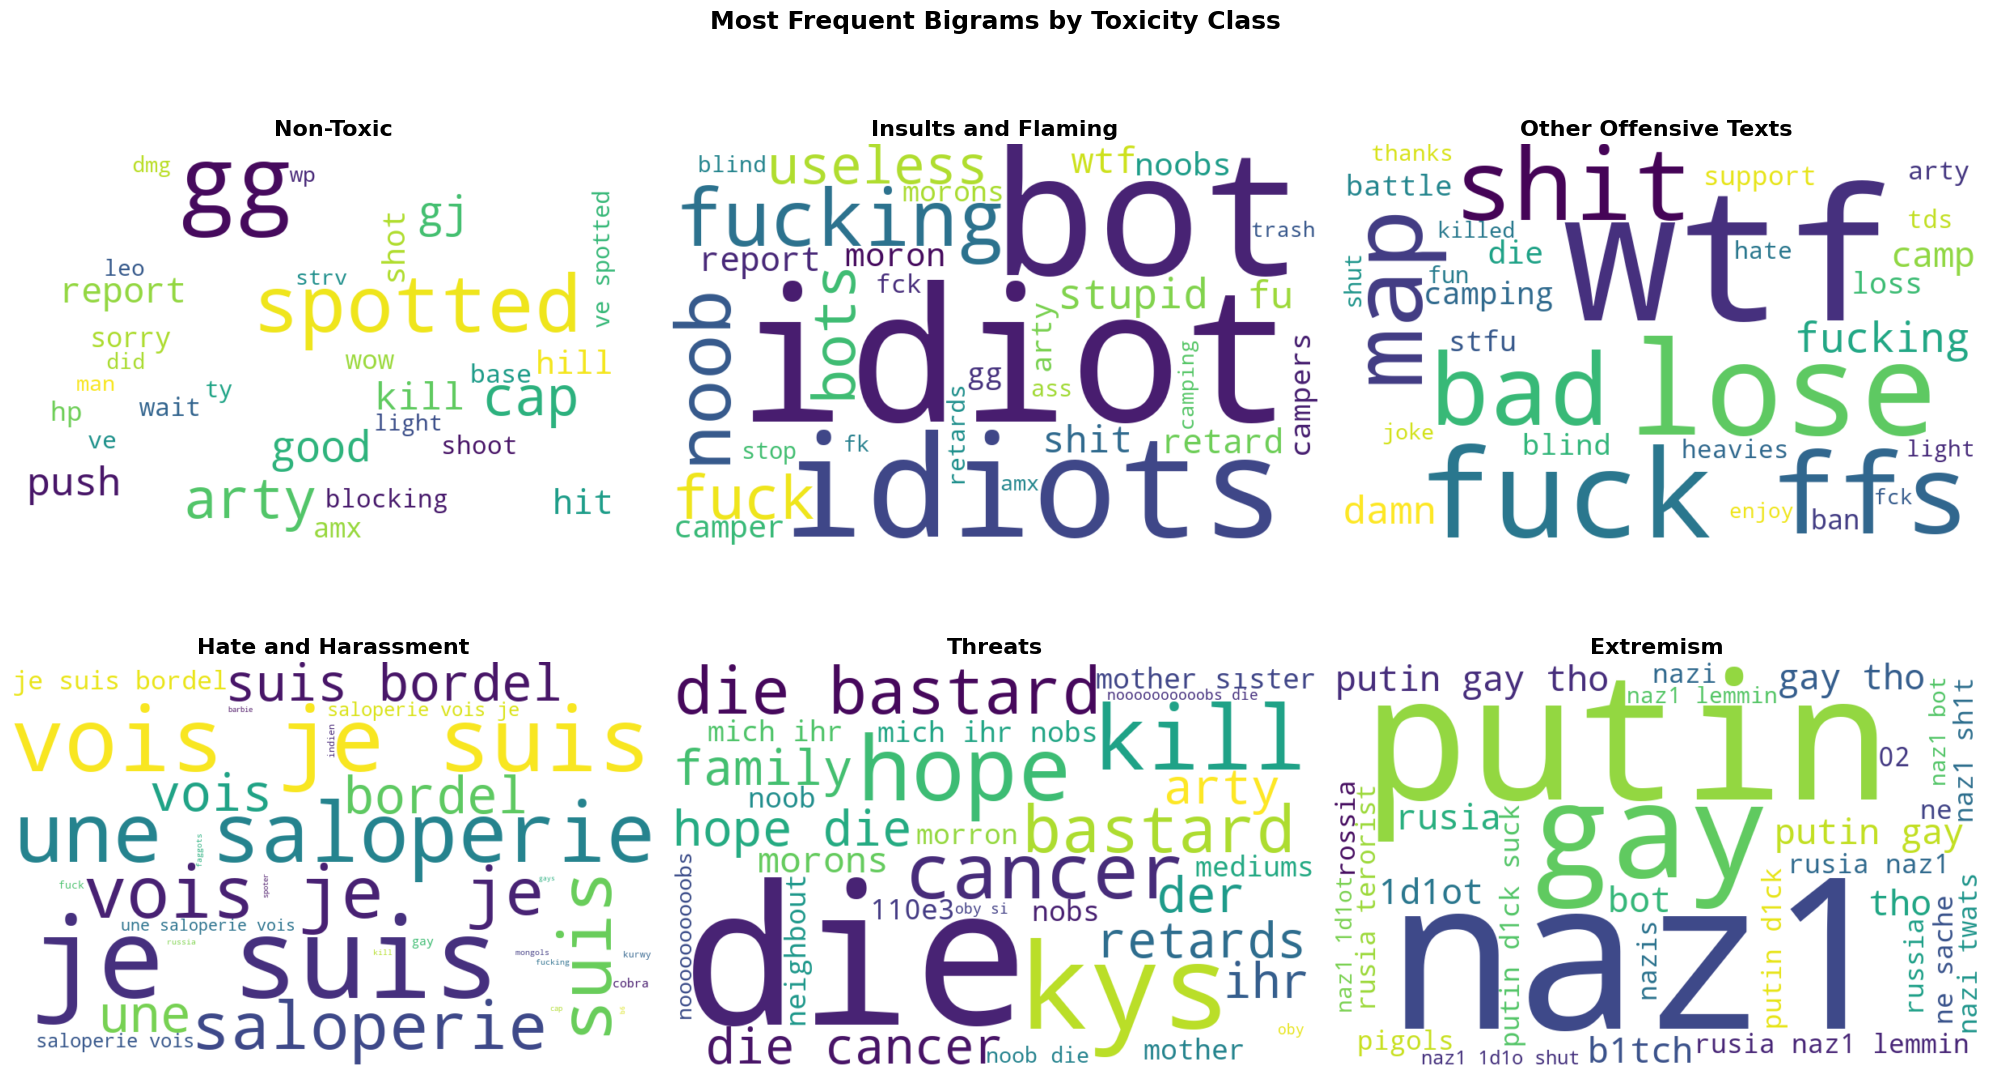

In [17]:
# class map
class_map = {
    0: "Non-Toxic",
    1: "Insults and Flaming",
    2: "Other Offensive Texts",
    3: "Hate and Harassment",
    4: "Threats",
    5: "Extremism"
}



# figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# create world clouds 
for i, cls in enumerate(sorted(train_df["label"].unique())):
    class_text = train_df.loc[train_df["label"] == cls, "message"].astype(str)
    
    # bigram vectorizer 
    bigram_vectorizer = CountVectorizer(
        # normalize accents
        strip_accents = "unicode", 
        # lowercase
        lowercase = True, 
        # stop words
        stop_words = list(STOPWORDS),
        max_df = 0.95,
        # ngram range
        ngram_range= (1, 3))
    
    
    # bigrams
    bigrams_trian = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_trian.sum(axis=0).A1
    bigram_names = bigram_vectorizer.get_feature_names_out()
    
    # bigrams frequency 
    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count": bigram_counts
    }).sort_values(by="count", ascending=False).head(30)
    

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], 
                                bigram_freq_train["count"]))
        
        # worcloud 
        wordcloud = WordCloud(
            width=800,
            height=500,
            background_color="white"
        ).generate_from_frequencies(bigram_dict)
        
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map[cls], fontweight="bold", fontsize=16)

# design
plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

### Pre-processing

| Feature | TweetTokenizer | Standard (split / CountVectorizer default) |
|---|---|---|
| Handles `@mentions`, `#hashtags` | Keeps as single token | Splits on `#`, `@` |
| Repeated chars (`looool`, `!!!!!!`) | Collapses to max 3 (`loool`, `!!!`) | Keeps full noise |
| Emoticons (`:)`, `:(`) | Preserved as tokens | Broken or dropped |
| Gaming shorthand (`gg`, `wtf`, `xD`) | Preserved as-is | Usually fine but no special handling |
| All-caps preservation | Configurable (`preserve_case`) | Not supported |
| Punctuation inside words | Handles intelligently | Often splits incorrectly |
| Informal language | Designed for it | Designed for formal text |

**Bottom line:** Gaming chat is structurally identical to Twitter - short, informal, abbreviation-heavy, emoticon-rich. TweetTokenizer was built for exactly this domain.


#### Save Splits

In [18]:
# save splits to parquet 
train_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_train_ml.parquet", index=False)
validation_df.to_parquet(PROJECT_ROOT / "data/processed_data/wot/wot_val_ml.parquet", index=False)


print("Saved:")
print(f"wot_train_ml.parquet - {train_df.shape}")
print(f"wot_val_ml.parquet - {validation_df.shape}")

Saved:
wot_train_ml.parquet - (44621, 3)
wot_val_ml.parquet - (4958, 2)


Three parquet files saved - one per split. 

## Dota 2 (CONDA)

In [19]:
# load Dota parquet
dota = pd.read_parquet(DATA_DIR_DOTA / "dota.parquet")
print(f"Dataset shape: {dota.shape}")
print(f"\nFirst 5 rows:\n{dota.head(5)}\n")
print(dota.info())

Dataset shape: (35749, 4)

First 5 rows:
   index  message  label  split
0  11263     wow!      0  train
1  13741      WTF      0  train
2  22125  wpe wpe      0  train
3   6453   hahaha      0  train
4   9644      wtf      0  train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35749 entries, 0 to 35748
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    35749 non-null  int64 
 1   message  35749 non-null  object
 2   label    35749 non-null  int64 
 3   split    35749 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB
None


### Exploratory Data Analysis (EDA)

| Class | Label |
|---|---|
| 0 | Other (non-toxic) |
| 1 | Ego |
| 2 | Aggression |
| 3 | Impolite |

#### Class distribution

In [20]:
print(f"Class distribution:\n{dota['label'].value_counts()}\n")
print(f"Class distribution (normalized):\n{dota['label'].value_counts(normalize=True)}")

Class distribution:
label
0    25713
1     4790
2     2711
3     2535
Name: count, dtype: int64

Class distribution (normalized):
label
0    0.719265
1    0.133990
2    0.075834
3    0.070911
Name: proportion, dtype: float64


C:\Users\nyuss\AppData\Local\Temp\ipykernel_25992\937577134.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
C:\Users\nyuss\AppData\Local\Temp\ipykernel_25992\937577134.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])


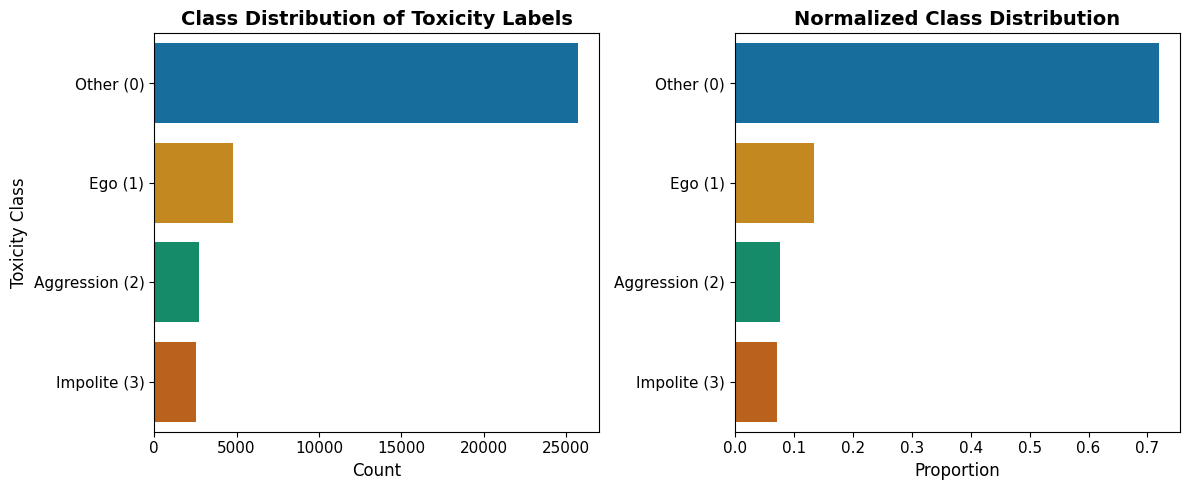

In [21]:
# distribution plot 
class_order_dota  = [0, 1, 2, 3]
class_labels_dota = ["Other (0)", "Ego (1)", "Aggression (2)", "Impolite (3)"]
label_map_dota    = dict(zip(class_order_dota, class_labels_dota))

dota["label_name"] = dota["label"].map(label_map_dota)

class_props = dota["label"].value_counts(normalize=True).reindex(class_order_dota)

# figure size 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first plot
sns.countplot(y="label_name", data=dota, order=class_labels_dota, palette="colorblind", ax=axes[0])
axes[0].set_title("Class Distribution of Toxicity Labels", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontsize=12)
axes[0].set_ylabel("Toxicity Class", fontsize=12)
axes[0].tick_params(labelsize=11)

# second plot
sns.barplot(x=class_props.values, y=class_labels_dota, palette="colorblind", ax=axes[1])
axes[1].set_title("Normalized Class Distribution", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Proportion", fontsize=12)
axes[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()

The distribution of classes in dota dataset is less imbalanced, but there is still imbalance. We again need to think about potential merging of classes, changing goal to binary classification or testing against multi-classification.

#### Non-English Messages (verification)

Dota 2 is a globally played game - non-ASCII messages are common. We drop them since we are building an English-only classifier.

In [22]:
# count non-ASCII messages
non_english_count = dota["message"].str.contains(NON_LATIN_SCRIPT, regex=True, na=False).sum()
print(f"Number of non-English script messages: {non_english_count}")
print(f"Percentage: {(non_english_count / len(dota)) * 100:.2f}%")


Number of non-English script messages: 0
Percentage: 0.00%


Everything's clean.

#### Word Frequency Analysis

In [23]:
# train/val split — stratified to preserve class proportions
X_dota = dota["message"]
y_dota = dota["label"]

X_dota_train, X_dota_val, y_dota_train, y_dota_val = train_test_split(
    X_dota, y_dota, test_size=0.10, random_state=seed, shuffle=True, stratify=y_dota
)

dota_train_df = pd.DataFrame({"message": X_dota_train, "label": y_dota_train}).reset_index(drop=True)
dota_val_df   = pd.DataFrame({"message": X_dota_val,   "label": y_dota_val}).reset_index(drop=True)

print(f"Train dataset shape: {dota_train_df.shape}")
print(f"Validation dataset shape: {dota_val_df.shape}")

Train dataset shape: (32174, 2)
Validation dataset shape: (3575, 2)


#### Number of words per document

In [24]:
# summary statistics of comment lengths
print("Summary statistics of comment lengths:")
dota_train_df["comment_length"] = dota_train_df["message"].str.split().str.len()
dota_train_df["comment_length"].describe()

Summary statistics of comment lengths:


count    32174.000000
mean         3.330173
std          3.199019
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         51.000000
Name: comment_length, dtype: float64

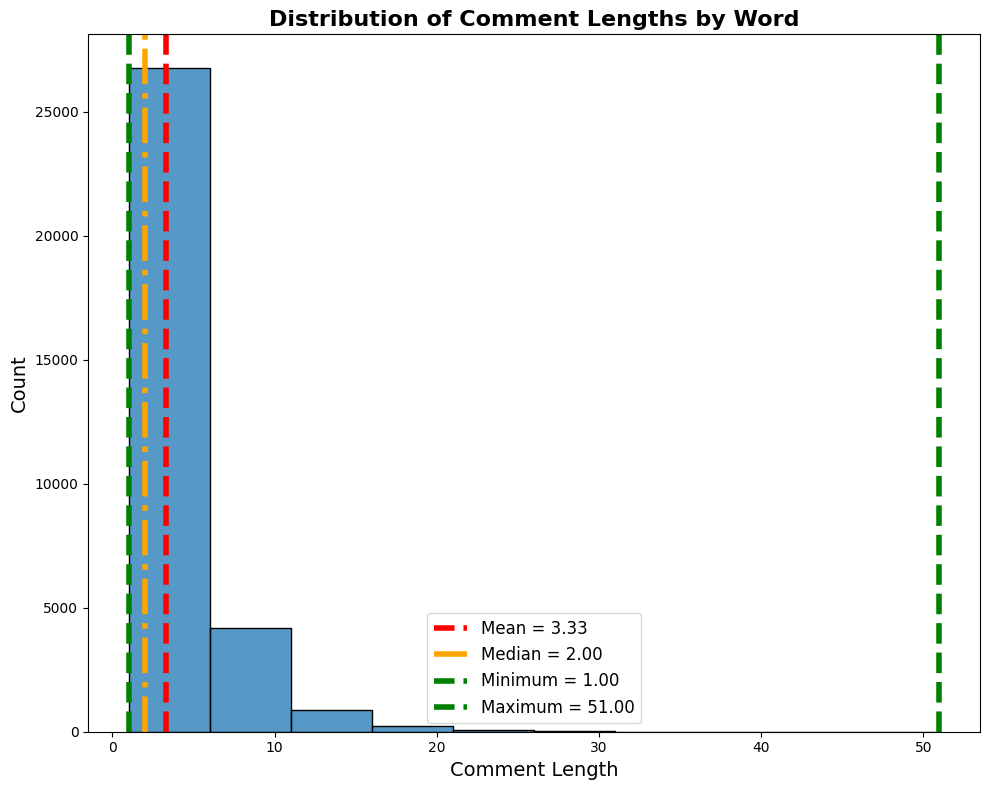

In [25]:
# distribution of comment lengths by word
mean_len   = dota_train_df["comment_length"].mean()
median_len = dota_train_df["comment_length"].median()
min_len    = dota_train_df["comment_length"].min()
max_len    = dota_train_df["comment_length"].max()

plt.figure(figsize=(10, 8))
sns.histplot(dota_train_df["comment_length"], bins=10, kde=False)

plt.axvline(mean_len,   linestyle="--", linewidth=4, label=f"Mean = {mean_len:.2f}",    color="red")
plt.axvline(median_len, linestyle="-.", linewidth=4, label=f"Median = {median_len:.2f}", color="orange")
plt.axvline(min_len,    linestyle="--", linewidth=4, label=f"Minimum = {min_len:.2f}",  color="green")
plt.axvline(max_len,    linestyle="--", linewidth=4, label=f"Maximum = {max_len:.2f}",  color="green")

plt.title("Distribution of Comment Lengths by Word", fontweight="bold", fontsize=16)
plt.xlabel("Comment Length", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Again, we can see than mean and median number of words in each message is ~2. We will utilize unigrams/bigrams for dota dataset as well.

In [26]:
# comments longer than or equal to the median top 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
0,XD) XD),2,0
1,i second what dooms saying,5,0
2,if our 4k ember wasn't dogshit,6,1
4,ez brain.,2,3
5,sorry can't buy items nor chat,6,0
8,??? happy birthday,3,0
9,worth it,2,0
11,ez mid,2,3
12,WOW 2 ULTIS,3,0
13,bh gg cant wait own team mate xD,8,2


In [27]:
# comments longer than or equal to the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] >= median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
32158,where the hell r u guys,6,1
32160,WOOOOW WHAT A SKILL,4,0
32161,TT when you win not when you lose hhaha,9,0
32163,i bet,2,0
32164,lol haha gg sf,4,0
32166,WHOS UR DADDY,3,0
32169,sory guys,2,0
32171,end this lc whit satanic only first art,8,0
32172,BASURA DE INVOKER,3,0
32173,QQ ,2,0


In [28]:
# comments shorter than the median top 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].head(10)

,message,comment_length,label
3,Np,1,0
6,LINA,1,0
7,gg,1,0
10,GG,1,0
16,gg,1,0
17,weak,1,0
22,XD,1,0
26,wp,1,0
27,ROFL,1,0
30,finish,1,2


In [29]:
# comments shorter than the median bottom 10 words
dota_train_df[dota_train_df["comment_length"] < median_len][["message", "comment_length", "label"]].tail(10)

,message,comment_length,label
32151,bl,1,0
32153,gg,1,0
32154,1000,1,0
32157,?,1,0
32159,y,1,0
32162,what?,1,0
32165,yamam,1,0
32167,XD,1,0
32168,XAXAXA,1,0
32170,pudge?,1,0


Messages are extremely short - median 2 words, max ~51 in train data. Dota 2 chat mirrors WoT: reaction-driven, not conversational. This confirms unigram + bigram TF-IDF is the right choice - trigrams would overfit to specific full messages rather than capturing reusable toxic patterns.

In [30]:
# top 20 most frequent words in training set
all_text = " ".join(X_dota_train.astype(str))
words = all_text.split()

word_freq = pd.DataFrame(Counter(words).items(), columns=["word", "count"])
word_freq = word_freq.sort_values(by="count", ascending=False)
word_freq.head(20)

,word,count
22,gg,2397
1,i,1410
129,u,1373
44,lol,1244
113,you,1237
13,ez,1092
74,is,898
99,?,886
142,a,830
57,me,821


In [31]:
# stopwords dictionary 
EXTRA = {
    # contractions sklearn misses
    "u", "ur", "im", "ive", "youre", "dont", "doesnt", "cant",
    "wont", "isnt", "wasnt", "didnt", "wouldnt", "couldnt",
    "thats", "its", "hes", "shes", "theyre", "weve",

    # pure filler
    "ok", "okay", "yeah", "yep", "nope", "nah",
    "oh", "ah", "uh", "um", "eh", "pls", "plz",
    "gonna", "gotta", "wanna", "tbh", "rly",

    # cross-class neutral bleed
    "just", "like", "time", "come", "win", "need",
    "xd", "guys", "lol", "omg", "thx", "rng",
    "play", "game", "tank", "spot",
    "today", "nice", "sry",
    "yes", "gl", "try", "let", "stay", "got", "left", "line",
    "elc", "ebr", "wg", "wot", "tier", "doing", "loose", "team", 
    "help", "afk", "lost", "dead", "commend", "pause",

    # Dota hero names — zero toxicity signal
    "abaddon", "alchemist", "axe", "bane", "batrider", "beastmaster",
    "bloodseeker", "brewmaster", "bristleback", "broodmother", "centaur",
    "chen", "clinkz", "clockwerk", "dazzle", "dawnbreaker", "disruptor",
    "doom", "enchantress", "enigma", "grimstroke", "gyrocopter", "hoodwink",
    "huskar", "invoker", "io", "jakiro", "juggernaut", "kunkka", "leshrac",
    "lich", "lifestealer", "lina", "lion", "luna", "lycan", "magnus",
    "marci", "mars", "medusa", "meepo", "mirana", "morphling", "muerta",
    "necrophos", "oracle", "pangolier", "phoenix", "puck", "pudge", "pugna",
    "razor", "riki", "rubick", "silencer", "slark", "slardar", "snapfire",
    "sniper", "spectre", "sven", "techies", "tidehunter", "timbersaw",
    "tinker", "tiny", "tusk", "underlord", "undying", "ursa", "viper",
    "visage", "warlock", "weaver", "zeus",

    # hero abbreviations
    "sf", "qop", "ta", "am", "es", "pa", "pl", "wk", "dk",
    "lc", "tb", "sk", "ns", "od", "wd", "sd", "ss", "kotl",
    "mk", "vs", "dp", "ck", "bh", "sb", "ember", "void", "storm",
    "jugg", "jug", "drow", "bara", "gyro", "legion", "rosh", "clock",
    "necro", "invo", "potm",
}

# append with sklearn dictionary
STOPWORDS = ENGLISH_STOP_WORDS.union(EXTRA)  # frozenset, O(1) lookup
print(STOPWORDS)

frozenset({'eh', 'elsewhere', 'just', 'nobody', 'kotl', 'broodmother', 'plz', 'as', 'every', 'didnt', 'alchemist', 'anything', 'myself', 'dazzle', 'has', 'gyrocopter', 'move', 'dp', 'mars', 'yet', 'anyway', 'many', 'back', 'wg', 'wanna', 'my', 'thereupon', 'therefore', 'tinker', 'ten', 'doesnt', 'lion', 'which', 'axe', 'amount', 'down', 'she', 'help', 'uh', 'jug', 'whereafter', 'mk', 'latterly', 'latter', 'fire', 'thick', 'forty', 'brewmaster', 'invo', 'mill', 'what', 'together', 'oh', 'juggernaut', 'ss', 'yourself', 'visage', 'is', 'becomes', 'well', 'void', 'take', 'hes', 'however', 'nah', 'six', 'of', 'hereby', 'although', 'up', 'in', 'whose', 'top', 're', 'twenty', 'jugg', 'mirana', 'could', 'though', 'always', 'riki', 'four', 'made', 'hereafter', 'gyro', 'by', 'puck', 'whereas', 'gl', 'had', 'they', 'if', 'slark', 'seems', 'dk', 'but', 'cant', 'game', 'wherever', 'rng', 'on', 'zeus', 'another', 'while', 'spot', 'qop', 'sometime', 'eleven', 'any', 'empty', 'beforehand', 'co', 'besi

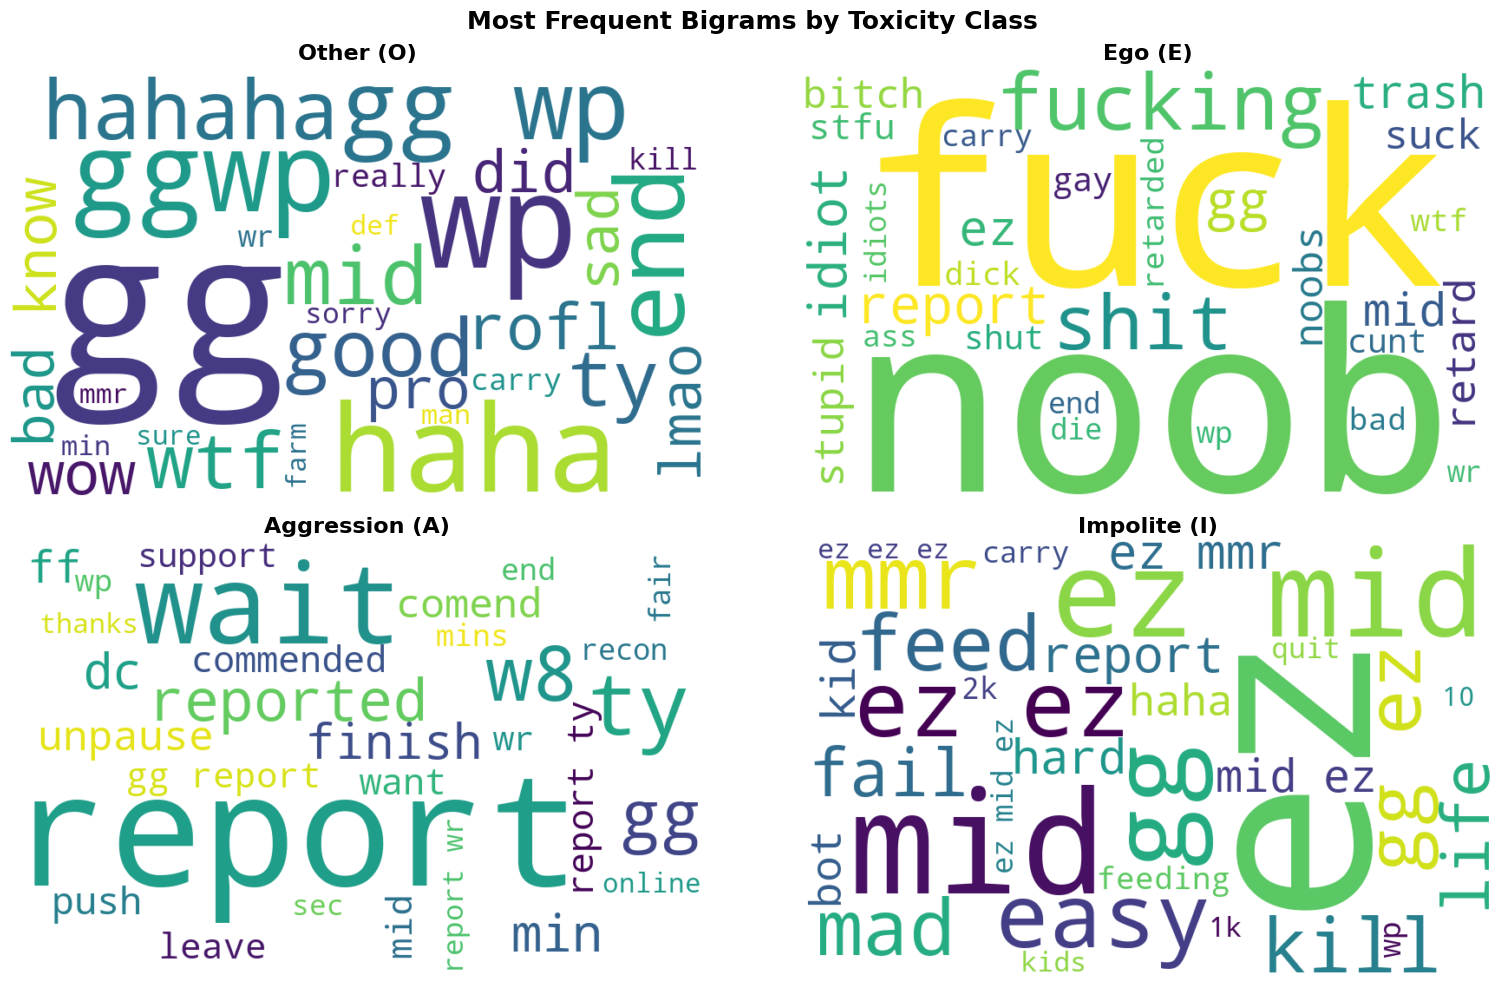

In [32]:
# same cloud plot for Dota dataset
class_map_dota = {0: "Other (O)", 1: "Ego (E)", 2: "Aggression (A)", 3: "Impolite (I)"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(sorted(dota_train_df["label"].unique())):
    class_text = dota_train_df.loc[dota_train_df["label"] == cls, "message"].astype(str)

    bigram_vectorizer = CountVectorizer(
        strip_accents="unicode",
        lowercase=True,
        stop_words=list(STOPWORDS),
        max_df=0.95,
        ngram_range=(1, 3)
    )

    bigrams_train = bigram_vectorizer.fit_transform(class_text)
    bigram_counts = bigrams_train.sum(axis=0).A1
    bigram_names  = bigram_vectorizer.get_feature_names_out()

    bigram_freq_train = pd.DataFrame({
        "bigram": bigram_names,
        "count":  bigram_counts
    }).sort_values(by="count", ascending=False).head(30)

    if len(bigram_freq_train) > 0:
        bigram_dict = dict(zip(bigram_freq_train["bigram"], bigram_freq_train["count"]))
        wordcloud = WordCloud(width=800, height=500, background_color="white").generate_from_frequencies(bigram_dict)
        axes[i].imshow(wordcloud, interpolation="bilinear")
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)
    else:
        axes[i].text(0.5, 0.5, "No bigrams found", ha="center", va="center", fontsize=12)
        axes[i].axis("off")
        axes[i].set_title(class_map_dota[cls], fontweight="bold", fontsize=16)

plt.suptitle("Most Frequent Bigrams by Toxicity Class", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

The classes are well-separated. Other (non-toxic) uses coordination language (gg, wp, nice). Ego centers on boasting and blame directed at teammates. Aggression uses direct insults and profanity. Impolite uses mild rudeness without explicit slurs - the most ambiguous class and hardest to distinguish from Ego.

- **Signals:**
    - Other (O): gg, wp, kill, carry, hard, bad, wtf - neutral game outcomes + sportsmanship

    - Ego (E): noob, fuck, fucking, shit, idiot, retard - skill attacks

    - Aggression (A): report, reported, reporting - behavior complaints dominate clearly

    - Impolite (I): ez, mid, easy, bot, life, kid, rage - condescension

### Pre-processing

Same TweetTokenizer pipeline as WoT - Dota 2 chat is structurally identical: short, informal, abbreviation-heavy. All-caps words (`REPORT`, `GG`) preserved for expressive intensity.

#### Save Splits

In [33]:
# save splits to parquet
dota_train_df.to_parquet(DATA_DIR_DOTA / "dota_train_ml.parquet", index=False)
dota_val_df.to_parquet(DATA_DIR_DOTA / "dota_val_ml.parquet", index=False)

print("Saved:")
print(f"dota_train_ml.parquet — {dota_train_df.shape}")
print(f"dota_val_ml.parquet  — {dota_val_df.shape}")

Saved:
dota_train_ml.parquet — (32174, 3)
dota_val_ml.parquet  — (3575, 2)
